# Preserve-root comparison on screws images

This notebook compares `preserve_root=False` and `preserve_root=True` in `ConnectedFilterPreprocessingLayer` using the screws image data.

The goal here is gray-level connected filtering, not direct segmentation training. In a max-tree, the root residue carries the global gray-level baseline. Preserving the root should keep that baseline even when non-root components are strongly suppressed. Filtering the root should allow the whole image, including the baseline, to be attenuated.

The CFP layer reconstructs from `uint8` tree altitudes. Since the dataset input is loaded in `[0, 1]`, the notebook explicitly divides CFP outputs by `255` before display and comparison.

In [7]:
# If running outside a local checkout and mtlearn is not installed, uncomment:
# %pip install mtlearn

from pathlib import Path
import math
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd()
for candidate in (repo_root, *repo_root.parents):
    if (candidate / "mtlearn" / "python" / "mtlearn").is_dir():
        repo_root = candidate
        local_python = repo_root / "mtlearn" / "python"
        if str(local_python) not in sys.path:
            sys.path.insert(0, str(local_python))
        break

import mtlearn
from mtlearn import morphology

SEED = 42
NUM_IMAGES = 3
DEVICE = "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("mtlearn:", mtlearn.__file__)
print("device:", DEVICE)

mtlearn: /Volumes/SSD/GitHub/mtlearn/mtlearn/python/mtlearn/__init__.py
device: cpu


## Load the same screws data

The loading flags mirror `Example_screws_filtering.ipynb`: grayscale input, inverted input, inverted target, resized images, and input scaled to `[0, 1]`. The target mask is shown only as context; it is not used as a loss target in this comparison.

In [8]:
num_cols, num_rows = (int(1177 * 0.5), int(1324 * 0.499))
dir_name = str(mtlearn.data.ensure_dataset("screws_segmentation"))

dataset = mtlearn.datasets.PairedImageDataset(
    root_dir=dir_name,
    grayscale_in=True,
    invert_in=True,
    invert_target=True,
    numRows=num_rows,
    numCols=num_cols,
    scale_in=True,
    suffix_in="_in",
    suffix_target="_target",
)

trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
samples = [testset[i] for i in range(min(NUM_IMAGES, len(testset)))]
inputs = torch.stack([sample[0] for sample in samples]).to(DEVICE)
targets = torch.stack([sample[1] for sample in samples]).to(DEVICE)
names = [sample[2] for sample in samples]

print("resolution:", num_cols, "x", num_rows)
print("dataset sizes:", len(trainset), "train /", len(testset), "test")
print("sample names:", names)
print("input range:", float(inputs.min()), float(inputs.max()))
print("target range:", float(targets.min()), float(targets.max()))

screws_segmentation: already available at /Volumes/SSD/GitHub/mtlearn/dat/screws_segmentation
resolution: 588 x 660
dataset sizes: 34 train / 15 test
sample names: ['14_in.jpg', '47_in.jpg', '49_in.jpg']
input range: 0.14901961386203766 0.9882352948188782
target range: 0.0 1.0


## Build two matched CFP specs

Both specs use the same max-tree, attributes, gain, and manually assigned gate value. The only difference is root handling:

- `root_filtered`: `preserve_root=False`, so the root residue is multiplied by the sigmoid gate.
- `root_preserved`: `preserve_root=True`, so the root residue is copied with gate one.

Weights are set to zero and bias sets a uniform gate probability. This isolates root semantics from attribute learning.

In [9]:
Type = morphology.AttributeType
attributes = (
    Type.AREA,
    Type.LENGTH_MAJOR_AXIS,
    Type.LENGTH_MINOR_AXIS,
    Type.INERTIA,
    Type.CIRCULARITY,
    Type.GRAY_HEIGHT,
    Type.RECTANGULARITY,
)

cfp_layer = mtlearn.layers.ConnectedFilterPreprocessingLayer(
    in_channels=1,
    filter_specs=[
        {
            "name": "root_filtered",
            "tree_type": morphology.TreeType.MAX_TREE,
            "attributes": attributes,
            "preserve_root": False,
        },
        {
            "name": "root_preserved",
            "tree_type": morphology.TreeType.MAX_TREE,
            "attributes": attributes,
            "preserve_root": True,
        },
    ],
    device=DEVICE,
    scale_mode="none",
    clamp=None,
)

def logit(p):
    p = min(max(float(p), 1e-6), 1.0 - 1e-6)
    return math.log(p / (1.0 - p))

def set_uniform_gate(layer, p):
    with torch.no_grad():
        for name in layer._weights:
            layer._weights[name].zero_()
            layer._biases[name].fill_(logit(p) / layer.beta_f)

def to_unit(raw_cfp):
    return torch.clamp(raw_cfp.float() / 255.0, 0.0, 1.0)

def summarize(label, tensor):
    x = tensor.detach().cpu().float()
    print(
        f"{label:>18s} | min={x.min():8.4f} max={x.max():8.4f} "
        f"mean={x.mean():8.4f} std={x.std():8.4f}"
    )

def run_filter(gate_probability):
    set_uniform_gate(cfp_layer, gate_probability)
    cfp_layer.eval()
    with torch.no_grad():
        raw = cfp_layer(inputs)
    return raw[:, 0], raw[:, 1]

def plot_comparison(title, raw_filtered, raw_preserved):
    filtered = to_unit(raw_filtered)
    preserved = to_unit(raw_preserved)
    diff = torch.abs(preserved - filtered)

    n = inputs.shape[0]
    fig, axes = plt.subplots(n, 5, figsize=(17, 3.5 * n), squeeze=False)
    fig.suptitle(title, y=1.01, fontsize=14)
    for i in range(n):
        panels = [
            (inputs[i, 0], "input"),
            (targets[i, 0], "target context"),
            (filtered[i], "preserve_root=False"),
            (preserved[i], "preserve_root=True"),
            (diff[i], "absolute difference"),
        ]
        for ax, (image, panel_title) in zip(axes[i], panels):
            vmax = 1.0 if panel_title != "absolute difference" else max(0.05, float(diff.max()))
            ax.imshow(image.detach().cpu(), cmap="gray", vmin=0.0, vmax=vmax)
            ax.set_title(panel_title if i == 0 else names[i])
            ax.axis("off")
    plt.tight_layout()
    plt.show()

print([spec["preserve_root"] for spec in cfp_layer.get_config()["filter_specs"]])

[False, True]


## Near identity gate

With a gate close to one, both outputs should be close to the input. The preserved-root output differs only by the small amount that would have been lost by gating the root with `p < 1`.

       input [0,1] | min=  0.1490 max=  0.9882 mean=  0.2748 std=  0.1260
      filtered raw | min= 37.8100 max=250.7400 mean= 69.7215 std= 31.9806
     preserved raw | min= 38.0000 max=250.9350 mean= 69.9148 std= 31.9806
    filtered [0,1] | min=  0.1483 max=  0.9833 mean=  0.2734 std=  0.1254
   preserved [0,1] | min=  0.1490 max=  0.9841 mean=  0.2742 std=  0.1254
preserved-filtered | min=  0.0007 max=  0.0008 mean=  0.0008 std=  0.0000


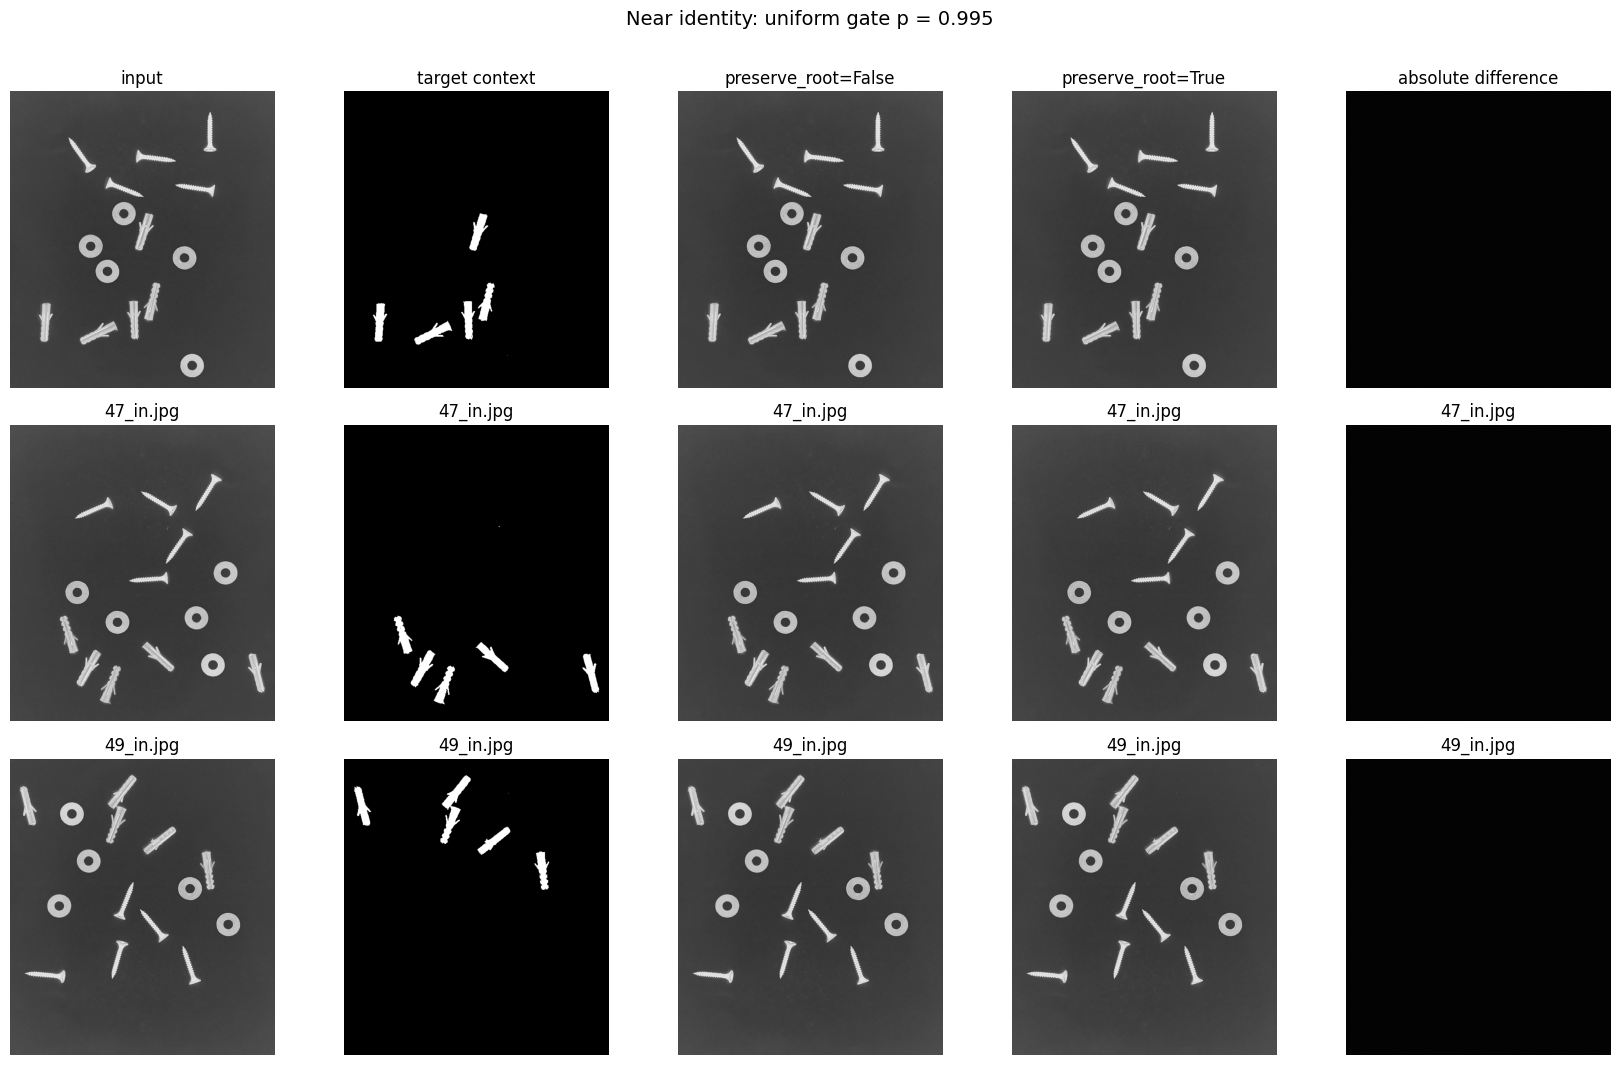

In [10]:
raw_filtered, raw_preserved = run_filter(gate_probability=0.995)

summarize("input [0,1]", inputs[:, 0])
summarize("filtered raw", raw_filtered)
summarize("preserved raw", raw_preserved)
summarize("filtered [0,1]", to_unit(raw_filtered))
summarize("preserved [0,1]", to_unit(raw_preserved))
summarize("preserved-filtered", to_unit(raw_preserved) - to_unit(raw_filtered))

plot_comparison("Near identity: uniform gate p = 0.995", raw_filtered, raw_preserved)

## Strong suppression gate

This is where root handling matters. With `p = 0.02`, `preserve_root=False` suppresses the whole image, including the global baseline. With `preserve_root=True`, non-root residues are suppressed but the image baseline remains. This is the intended gray-level filtering interpretation.

       input [0,1] | min=  0.1490 max=  0.9882 mean=  0.2748 std=  0.1260
      filtered raw | min=  0.7600 max=  5.0400 mean=  1.4014 std=  0.6428
     preserved raw | min= 38.0000 max= 43.2600 mean= 39.2948 std=  0.7927
    filtered [0,1] | min=  0.0030 max=  0.0198 mean=  0.0055 std=  0.0025
   preserved [0,1] | min=  0.1490 max=  0.1696 mean=  0.1541 std=  0.0031
preserved-filtered | min=  0.1460 max=  0.1499 mean=  0.1486 std=  0.0018


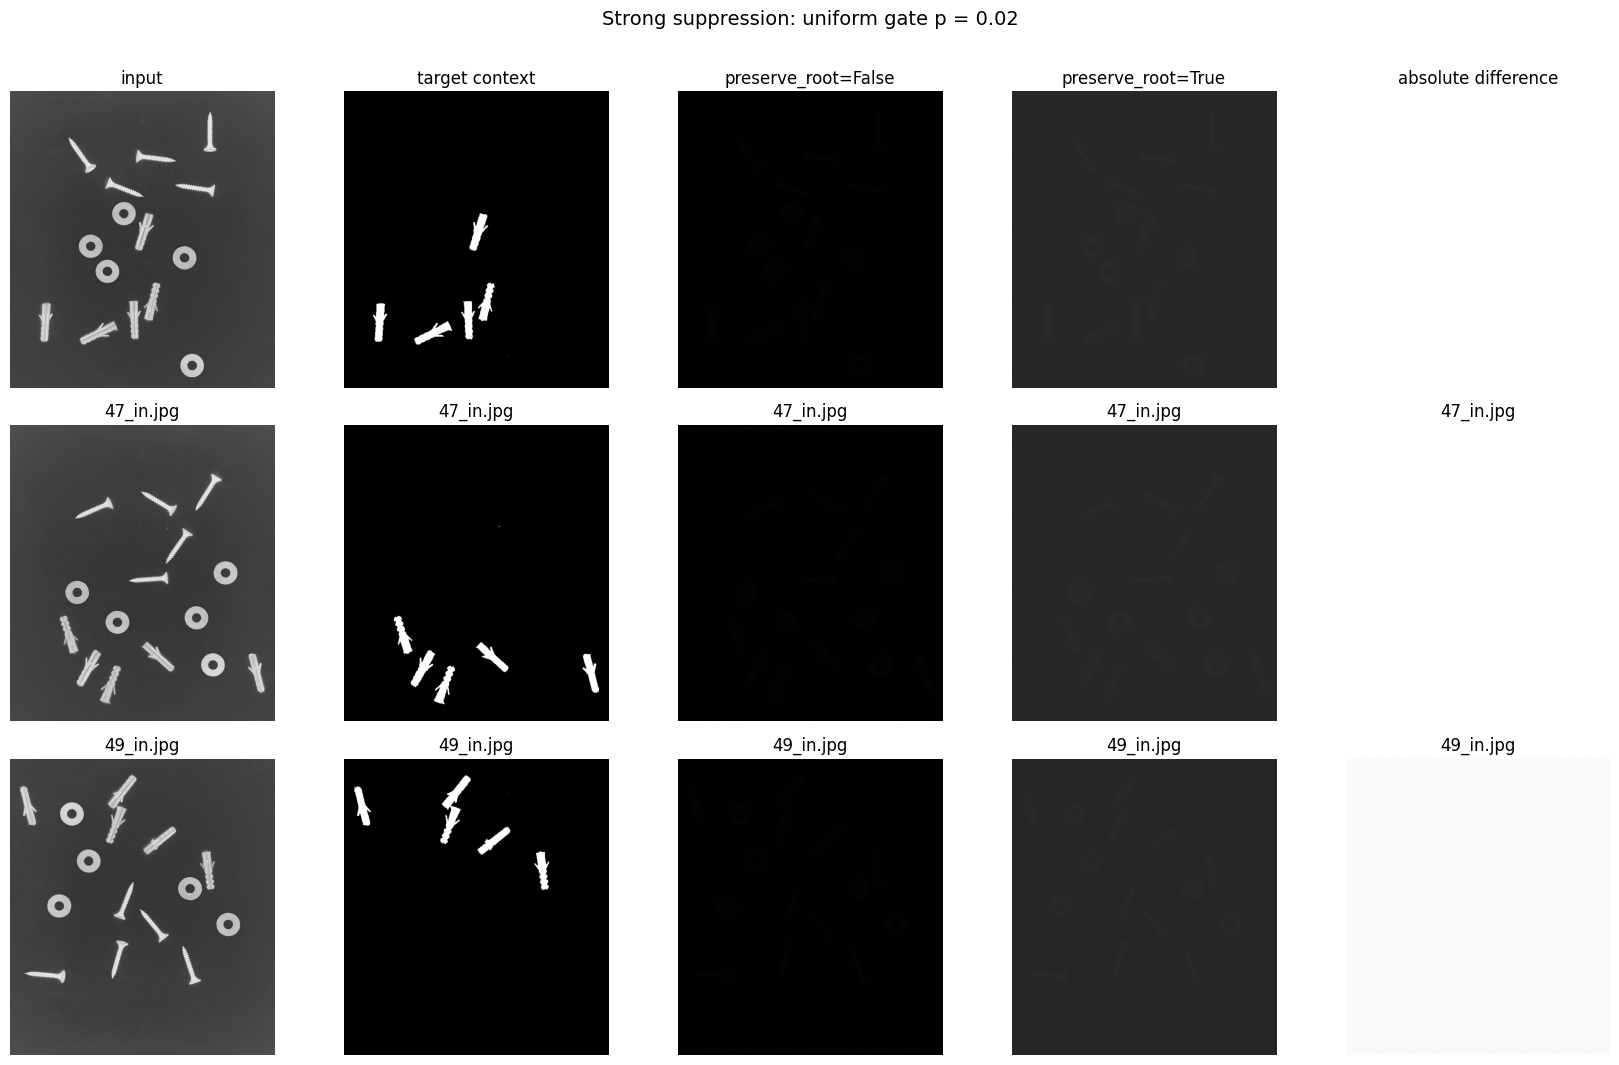

In [5]:
raw_filtered, raw_preserved = run_filter(gate_probability=0.02)

summarize("input [0,1]", inputs[:, 0])
summarize("filtered raw", raw_filtered)
summarize("preserved raw", raw_preserved)
summarize("filtered [0,1]", to_unit(raw_filtered))
summarize("preserved [0,1]", to_unit(raw_preserved))
summarize("preserved-filtered", to_unit(raw_preserved) - to_unit(raw_filtered))

plot_comparison("Strong suppression: uniform gate p = 0.02", raw_filtered, raw_preserved)

## Constant-image sanity check

For a constant image, the max-tree has only the baseline component. If the root is filtered, the constant value is attenuated. If the root is preserved, the constant image is reconstructed unchanged up to the `uint8` conversion used by tree construction.

    constant input | min=  0.3500 max=  0.3500 mean=  0.3500 std=  0.0000
     root filtered | min=  0.0070 max=  0.0070 mean=  0.0070 std=  0.0000
    root preserved | min=  0.3490 max=  0.3490 mean=  0.3490 std=  0.0000


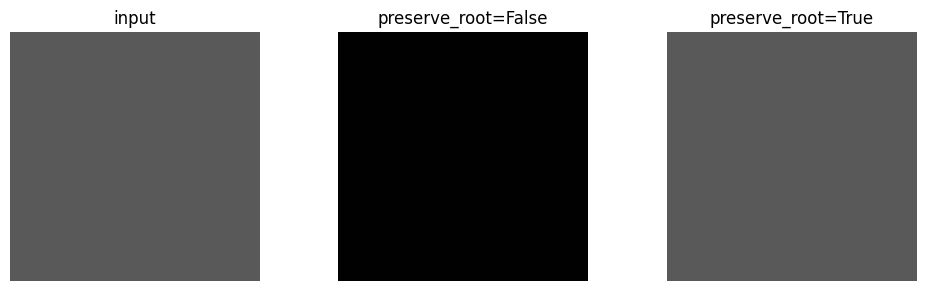

In [6]:
constant_layer = mtlearn.layers.ConnectedFilterPreprocessingLayer(
    in_channels=1,
    filter_specs=[
        {
            "name": "constant_root_filtered",
            "tree_type": morphology.TreeType.MAX_TREE,
            "attributes": (Type.AREA,),
            "preserve_root": False,
        },
        {
            "name": "constant_root_preserved",
            "tree_type": morphology.TreeType.MAX_TREE,
            "attributes": (Type.AREA,),
            "preserve_root": True,
        },
    ],
    device=DEVICE,
    scale_mode="none",
    clamp=None,
)

set_uniform_gate(constant_layer, p=0.02)
constant_input = torch.full((1, 1, 64, 64), 0.35, device=DEVICE)
with torch.no_grad():
    constant_raw = constant_layer(constant_input)

constant_filtered = to_unit(constant_raw[:, 0])
constant_preserved = to_unit(constant_raw[:, 1])

summarize("constant input", constant_input[:, 0])
summarize("root filtered", constant_filtered)
summarize("root preserved", constant_preserved)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, image, title in [
    (axes[0], constant_input[0, 0], "input"),
    (axes[1], constant_filtered[0], "preserve_root=False"),
    (axes[2], constant_preserved[0], "preserve_root=True"),
]:
    ax.imshow(image.detach().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Interpretation

- Use `preserve_root=True` when the CFP is used as a gray-level connected filter and preserving the global baseline is part of the desired operator semantics.
- Use `preserve_root=False` when the objective is allowed to suppress the entire image baseline, such as a direct mask-regression setup where the target background is zero.
- Do not compare raw CFP output to a `[0, 1]` target without rescaling. Raw altitude reconstruction is in `uint8` units, so divide by `255` for display or losses in `[0, 1]`.